# Lecture 15: Making our helicopter hover with proportional control

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/engr1050-fall2026/blob/main/NewMaterial/Lecture15/lec15.ipynb)

> Click the badge above to open this notebook in Google Colab. You are also welcome to run notebooks in your own environment (VSCode, jupyter-notebook server, etc) if you know how to do that, but for now this link will let you get started without configuring your computer.

Today we will calibrate a simple model for the helicopter to the data we collected in the last lab. This will look like the last few lectures where we numerically solved ODEs.

At the end of today's lecture, you'll know how to:

- Use `pickle` to read in data from the experiment we did in lab.
- Use your simulator to calibrate an ODE that matches actual measurements.
- Use that model to design a control that makes the helicopter hover.

### Set up data environment

Run the following code block to make sure that your colab instance has access to the data.

In [ ]:
import json
import os
import urllib.request  
os.makedirs('Images', exist_ok=True)
print('Images/ directory ensured')

os.makedirs('Data', exist_ok=True)
print('Data/ directory ensured')


# Download student datasets file for local use
dataset_url = "https://github.com/natrask/engr1050-fall2026/raw/main/NewMaterial/_shared/Data/student_datasets.pkl"
local_dataset_path = "Data/student_datasets.pkl"

if not os.path.exists(local_dataset_path):
    print("Downloading student datasets...")
    urllib.request.urlretrieve(dataset_url, local_dataset_path)
    print("Downloaded student_datasets.pkl to Data/ directory")
else:
    print("student_datasets.pkl already exists in Data/ directory")

Images/ directory ensured
Data/ directory ensured
student_datasets.pkl already exists in Data/ directory


# Access data using pickle

I stored the results of everyone's experiments as a "Pickle" file. `Pickle` is a Python package for storing and loading objects from the disk. It makes it very painless to save complex Python data structures (lists, dictionaries, custom objects) to files and reload them later. There is basically a single `dump` function to write to disk and a `load` function to read from disk.

## Basic pickle syntax

```python
import pickle

# Save an object to a file
with open('filename.pkl', 'wb') as f:
    pickle.dump(my_object, f)

# Load an object from a file
with open('filename.pkl', 'rb') as f:
    my_object = pickle.load(f)
```

**Key points:**
- Use `'wb'` (write binary) mode when saving
- Use `'rb'` (read binary) mode when loading
- Pickle can handle most Python objects: lists, dicts, classes, functions, etc.
- Files typically use `.pkl` extension

## Common usage examples

**Example 1: Save and load a list of experimental data**
```python
import pickle

# Save experimental results
results = [[1.2, 3.4], [2.1, 5.6], [3.0, 7.8]]
with open('Data/experiment_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Load them back later
with open('Data/experiment_results.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
print("Loaded:", loaded_results)
```

**Example 2: Save multiple objects in one file**
```python
# Save multiple variables together
student_names = ["Alice", "Bob", "Charlie"]
test_scores = [85, 92, 78]
class_average = 85.0

data_to_save = {
    'names': student_names,
    'scores': test_scores,
    'average': class_average
}

with open('Data/class_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

# Load everything back
with open('Data/class_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Look at available keys
print("Available objects: ", loaded_data.keys())

# Get objects back out
names = loaded_data['names']
scores = loaded_data['scores']
avg = loaded_data['average']
```

**Example 3: Load our helicopter dataset**
```python
import pickle

# Load the student datasets we downloaded earlier
with open('Data/student_datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

```

**When to use pickle:**
- Saving processed experimental data for later analysis
- Storing intermediate results from long computations
- Sharing complex Python objects between programs
- Creating backups of your work

### Exercise

Use pickle to load the Data/student_datasets.pkl file. Choose one of the datasets to work with for the rest of this exercise - you'll want one that has some good wiggles in it.

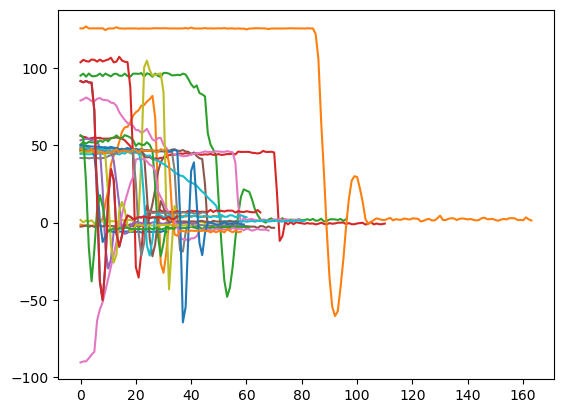

In [96]:
import pickle

# Load the student datasets we downloaded earlier
with open('Data/student_datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Plot available datasets
import matplotlib.pyplot as plt
for dataset in datasets:
    plt.plot(dataset[2])  # Show available datasets

There is a whole pile of datasets in here. I made it easier for you by choosing what looks like the cleanest experiment from the class (*experiment #11*) and trimmed it down to give us all a common experiment to try to reproduce. In principle you could have done this directly on your personal data on the lab, but not everybody was able to get a nice clean profile.

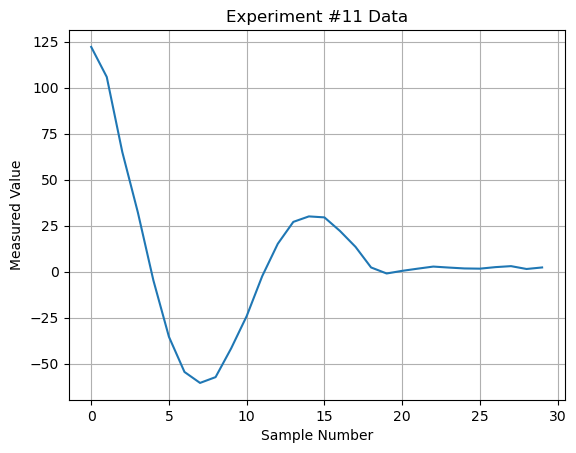

In [97]:
import numpy as np

# Select a dataset to plot
whichSet = 11 # Change this number to plot a different dataset
goodExperiment = np.array(datasets[whichSet][2][85:115])
plt.figure()
plt.plot(goodExperiment)
plt.title(f'Experiment #{whichSet} Data')
plt.xlabel('Sample Number')
plt.ylabel('Measured Value')
plt.grid()

# Model with an ODE using our `ODEsolver` class

I've copied the base `ODE_solver` class from previous lectures here.

In [98]:
class ODE_solver:
    def __init__(self, t0, tf, y0, N):
        self.y0 = y0  # initial condition as numpy array
        self.t0 = t0  # initial time as float
        self.tf = tf  # final time as float
        self.N = N    # number of steps as integer
        self.h = (tf - t0) / float(N) # timestep size

        # We need to check what size y0 is and store that information
        self.dim = len(y0) #assumes that y0 is a list or array

        # Create a place to store the solution
        self.t_values = np.array([t0 + i*self.h for i in range(N+1)])  # time values
        self.solution = np.zeros((N+1, self.dim))  # solution array
        self.solution[0, :] = y0  # set initial condition
        
    def f(self,t,y):
        # Define the right-hand side of the ODE here, assuming a scalar t and a numpy array y
        # Example: dy/dt = -2y (for scalar y),
        # this function should return a numpy array of the same shape as y
        f = np.zeros_like(y)
        f[0] = -2 * y[0]  # Example for the first component
        return f
    
    def solve(self):
        # Implement explicit euler: y_n+1 = y_n + h*f(t_n, y_n)
        for n in range(self.N):
            t_n = self.t_values[n]
            y_n = self.solution[n, :]
            f_n = self.f(t_n, y_n)
            self.solution[n+1, :] = y_n + self.h * f_n
        return self.solution

In lecture we highlighted how to inherit from this base class to get a nonlinear pendulum.

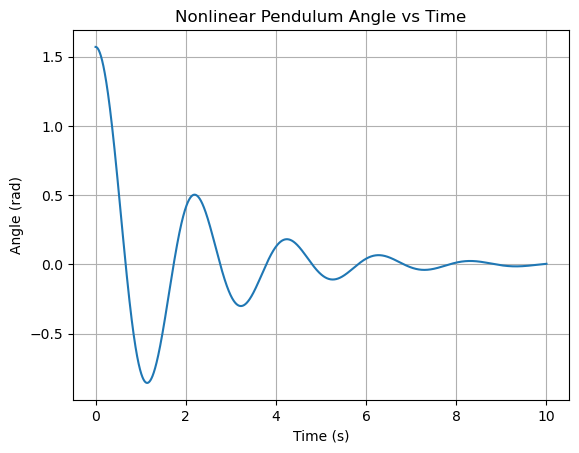

In [100]:
class nonlinearPendulum_solver(ODE_solver):
    def __init__(self, t0, tf, y0, N,b,K):
        super().__init__(t0, tf, y0, N)
        # Additional parameters for friction and forcing
        self.b = b  # friction coefficient
        self.K = K  # g/L term
    def f(self,t,y):
        # Define the right-hand side of the ODE here, assuming a scalar t and a numpy array y
        # b and K are specified as inputs to make it easy to play with them
        g = 9.81  # acceleration due to gravity
        L = 1.0   # length of the pendulum
        T = 0.0   # Forcing term to add torque (0 for now)
        f = np.zeros_like(y)
        f[0] = y[1]
        f[1] =  - self.b*y[1] - self.K*np.sin(y[0]) + T
        return f

#Example solve - solve with b = 0.1 and g/L = 9.81
pendulum = nonlinearPendulum_solver(
    t0=0, 
    tf=10, 
    y0=np.array([np.pi/2, 0]), 
    N=10000,
    b=1.0,
    K=9.81
    )
solution = pendulum.solve()

import matplotlib.pyplot as plt
plt.figure()
plt.plot(pendulum.t_values, solution[:,0])
plt.title('Nonlinear Pendulum Angle vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.grid()
plt.show()

**Your job:** This code is good to go to run your own virtual experiments. If you set  the initial condition and the parameters, you can see different trajectories. Your job is to find a good choice of $\beta$ and $K$ so that the model matches the experiment.

*Hints:*
The are two parameters that you can play with. One of them will set the frequency response, while the other sets the decay. To start, turn off the friction to match the wavelength of the data, then calibrate the friction so that your ODE decays at the same rate as the experimental data.

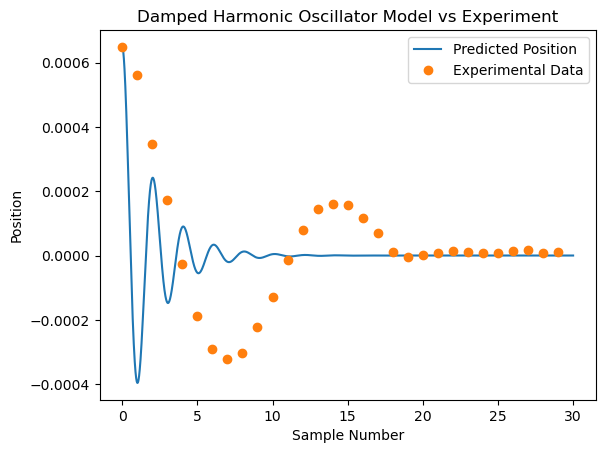

In [108]:
# Convert data from degrees to radians
goodExperiment = np.radians(goodExperiment)

# Solve model for a choice of b and K - your job is to tune these!
mySolve = nonlinearPendulum_solver(
    t0=0, 
    tf=len(goodExperiment), 
    y0=np.array([goodExperiment[0], 0]), 
    N=10000,
    b=1.0,
    K=9.81
    )

t_values = mySolve.t_values
solution = mySolve.solve()
plt.figure()
plt.plot(t_values, solution[:,0], label='Predicted Position')
plt.plot(range(len(goodExperiment)), goodExperiment, 'o', label='Experimental Data')
plt.title('Damped Harmonic Oscillator Model vs Experiment')
plt.xlabel('Sample Number')
plt.ylabel('Position')
plt.legend()

# Design a hover policy using proportional control

Awesome - you now have a model for the system! There are some parameters that we can set by hand (e.g. by measuring the weight and length of the pendulum) but others are tricky to set (the friction coefficient). Now that we have a model that does a reasonable job at predicting the system, we can use it to design a policy for the motor to hover around a target angle.

To do this we can use **proportional control**: we will set the power sent to the fan to be proportional to how far we are from a desired angle.
$$ T = C K_p (\theta_{target} - \theta) $$
where $T$ is the torque applied to the pendulum, $K_p$ is the power supplied to the motor, $\theta_{target}$ is the desired angle to reach, and $C$ is a constant that we can calibrate to model the aerodynamics of the helicopter. 

In practice we would calibrate $C$ from experiment in the same way we calibrated $\beta$. To keep this exercise simple, we'll just set $C=1$.

# Exercise

Modify the helicopter system using the model we've calibrated to data, adding the additional forcing term. Check how the model response varies as a function of $K_p$. If you don't give enough juice to the motor it won't run (the $K_p=0$ limit corresponds exactly to the experiment we did in lab last week!).

**Your task:** Generate plots for many different values of $K_p$ and write a short markdown comment summarizing your observations. For what value of $K_p$ does the control "work"? 

To get you started, I've copied and pasted the code that you'll need to modify to add the control policy. I modified the input so that you can modify the `f` function to account for the control. Right now $\mathbf{T}=0$, which means the fan does nothing at all. Remember that the new ODE should be:

$$\dot{y_1} = y_2$$
$$\dot{y_2} = - b y_2 - K \sin(y_1) + T $$
$$ T = K_p (\theta_{\text{target}} - y_1) $$

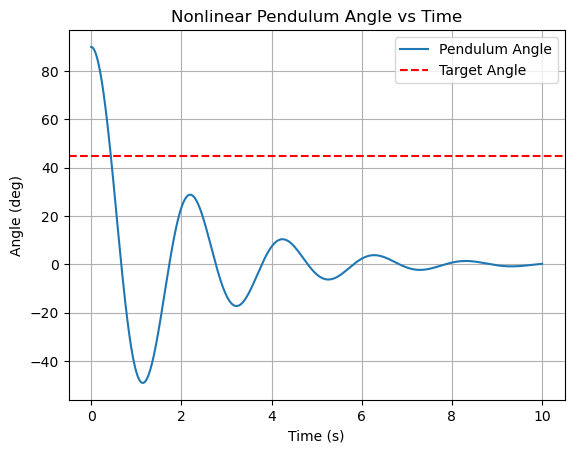

In [ ]:
class nonlinearPendulum_PLUS_CONTROL_solver(ODE_solver):
    def __init__(self, t0, tf, y0, N,b,K, Kp, theta_target): ### Two new parameters!
        super().__init__(t0, tf, y0, N)
        # Additional parameters for friction and forcing
        self.b = b  # friction coefficient
        self.K = K  # g/L term
        self.Kp = Kp  # Proportional gain for control ### NEW!
        self.theta_target = theta_target  # Target angle for control ### NEW!

    def f(self,t,y):
        # Define the right-hand side of the ODE here, assuming a scalar t and a numpy array y
        # b and K are specified as inputs to make it easy to play with them
        g = 9.81  # acceleration due to gravity
        L = 1.0   # length of the pendulum
        T = 0.0   # Replace this with a control law!
        f = np.zeros_like(y)
        f[0] = y[1]
        f[1] =  - self.b*y[1] - self.K*np.sin(y[0]) + T
        return f
    
# Example solve
targetTheta = np.pi/4.0  # 45 degrees in radians

pendulum = nonlinearPendulum_PLUS_CONTROL_solver(
    t0=0, 
    tf=10, 
    y0=np.array([np.pi/2, 0]), 
    N=10000,
    b=1.0,
    K=9.81,
    Kp=10.0,  # Proportional gain for control ### PLAY WITH THIS
    theta_target=targetTheta # 45 degree target control
    )
solution = pendulum.solve()

import matplotlib.pyplot as plt
plt.figure()
plt.plot(pendulum.t_values, solution[:,0]*180/np.pi,label='Pendulum Angle') 
plt.title('Nonlinear Pendulum Angle vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Angle (deg)')
# Plot target as horizontal line
plt.axhline(y=targetTheta*180/np.pi, color='r', linestyle='--', label='Target Angle')
plt.legend()
plt.grid()
plt.show()

# Submit today's work #
Unfortunately, Canvas is down today due to the Amazon Web Services crash. We will not collect this assignment. Make sure you save it however because you **will need this code to complete HW4**. If you finish early, take a shot at completing [Homework 4](https://github.com/natrask/engr1050-fall2026/blob/main/NewMaterial/Homeworks/HW4/hw4.pdf)



You **should not need to use AI** to complete this assignment; if you are lost on using our `ODE_integrator` code then make sure you get either Dr. Trask or Ben to come and help you. Discussion with your neighbors is welcome. Attribute any external resources you used here to comply with Penn's academic integrity policy.